# **Accessing CMIP6 data with intake catalogs**

This notebook is useful if you want to easily browse data in the shared folders on the jupyterhub and online.
You can read more about how the catalogs and intake work [here](https://intake-esm.readthedocs.io/en/stable/).

In [1]:
import intake_esm
import intake
import pandas
import xarray
import gcsfs
import matplotlib as mpl
import cartopy.crs as ccrs
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=xarray.SerializationWarning)


### Catalogs with local data:
In `/mnt/clinfra-ns12127k/catalogs/` you can find catalog files `cmip6.json`, `merged_cmip6.json` and `noresm.json`. First two contain a local subset of CMIP6 data from different models, `noresm.json` contains only NorESM CMIP6 data + additional simulations from different MIPs.

In [ ]:
# open a catalog from a file:
local_cmip6_catalog = intake.open_esm_datastore('/mnt/clinfra-ns12127k/catalogs/merged_local.json')
#open noresm catalog
noresm_catalog = intake.open_esm_datastore('/mnt/clinfra-ns12127k/catalogs/noresm.json')
# the output of this is an object based panda dataframe class, and next statement will print out a summary of it
local_cmip6_catalog

,unique
variable_id,329
table_id,23
source_id,73
experiment_id,23
member_id,189
grid_label,11
time_range,7657
activity_id,4
institution_id,34
version,528


### Let's also open an online catalog with CMIP6 data provided by [Pangeo](https://pangeo-data.github.io/pangeo-cmip6-cloud/overview.html)
`/mnt/clinfra-ns12127k/catalogs/merged_cmip6.json` contains only a subset of CMIP6 data. Intake allows for accessing catalogs and associated data from a remote server/location.  A publically available pandge-cmip6 catalog can contain data that is missing in the local catalog and which you might want to access. 90% of the time it's the catalog you want to search through first.

In [3]:
# you can notice that the catalog .json file does not have to be stored locally on a server:
pangeo_cmip6_catalog = intake.open_esm_datastore("https://storage.googleapis.com/cmip6/pangeo-cmip6.json")
pangeo_cmip6_catalog

,unique
activity_id,18
institution_id,36
source_id,88
experiment_id,170
member_id,657
table_id,37
variable_id,700
grid_label,10
zstore,514818
dcpp_init_year,60


#### Accessing underlying dataframe:
Each catalog contains a pandas dataframe (which is read from the .csv file f.e. `merged_local.csv`). The catalog object itself just has some extra things going on.

In [4]:
# pandas dataframes have .head() method that prints first few lines of the dataframe:
local_cmip6_catalog.df.head()

,variable_id,table_id,source_id,experiment_id,member_id,grid_label,time_range,activity_id,institution_id,version,path,dcpp_init_year,format
0,tas,Amon,TaiESM1,1pctCO2,r1i1p1f1,gn,000101-015012,clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6,AS-RCEC,20200225,/mnt/clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6/AS-RCEC/TaiESM1/1pctCO...,NaN,netcdf
1,hus,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6,AS-RCEC,20200310,/mnt/clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
2,pr,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6,AS-RCEC,20200310,/mnt/clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
3,rlut,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6,AS-RCEC,20200310,/mnt/clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf
4,rlutcs,Amon,TaiESM1,abrupt-4xCO2,r1i1p1f1,gn,000101-015012,clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6,AS-RCEC,20200310,/mnt/clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6/AS-RCEC/TaiESM1/abrupt...,NaN,netcdf


In [5]:
#same for pangeo-cmip6
pangeo_cmip6_catalog.df.head()

,activity_id,institution_id,source_id,experiment_id,member_id,table_id,variable_id,grid_label,zstore,dcpp_init_year,version
0,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,ps,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
1,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rsds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
2,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlus,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
3,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,rlds,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706
4,HighResMIP,CMCC,CMCC-CM2-HR4,highresSST-present,r1i1p1f1,Amon,psl,gn,gs://cmip6/CMIP6/HighResMIP/CMCC/CMCC-CM2-HR4/...,NaN,20170706


### One of the useful functions of the catalog object `.unique()` can be used to have a quick peek at what data is available.

In [6]:
# this will output all the unique sourc_id's (models) that are present in any activity_id, experiment_id etc.
pangeo_cmip6_catalog.unique()['source_id']

['CMCC-CM2-HR4',
 'EC-Earth3P-HR',
 'HadGEM3-GC31-MM',
 'HadGEM3-GC31-HM',
 'HadGEM3-GC31-LM',
 'EC-Earth3P',
 'ECMWF-IFS-HR',
 'ECMWF-IFS-LR',
 'HadGEM3-GC31-LL',
 'CMCC-CM2-VHR4',
 'GFDL-CM4',
 'GFDL-AM4',
 'IPSL-CM6A-LR',
 'E3SM-1-0',
 'CNRM-CM6-1',
 'GFDL-ESM4',
 'GFDL-ESM2M',
 'GFDL-CM4C192',
 'GFDL-OM4p5B',
 'GISS-E2-1-G',
 'GISS-E2-1-H',
 'CNRM-ESM2-1',
 'BCC-CSM2-MR',
 'BCC-ESM1',
 'MIROC6',
 'AWI-CM-1-1-MR',
 'EC-Earth3-LR',
 'IPSL-CM6A-ATM-HR',
 'CESM2',
 'CESM2-WACCM',
 'CNRM-CM6-1-HR',
 'MRI-ESM2-0',
 'SAM0-UNICON',
 'GISS-E2-1-G-CC',
 'UKESM1-0-LL',
 'EC-Earth3',
 'EC-Earth3-Veg',
 'FGOALS-f3-L',
 'CanESM5',
 'CanESM5-CanOE',
 'INM-CM4-8',
 'INM-CM5-0',
 'NESM3',
 'MPI-ESM-1-2-HAM',
 'CAMS-CSM1-0',
 'MPI-ESM1-2-LR',
 'MPI-ESM1-2-HR',
 'MRI-AGCM3-2-H',
 'MRI-AGCM3-2-S',
 'MCM-UA-1-0',
 'INM-CM5-H',
 'KACE-1-0-G',
 'NorESM2-LM',
 'FGOALS-f3-H',
 'FGOALS-g3',
 'MIROC-ES2L',
 'FIO-ESM-2-0',
 'NorCPM1',
 'NorESM1-F',
 'MPI-ESM1-2-XR',
 'CESM1-1-CAM5-CMIP5',
 'E3SM-1-1',
 'KIOST

## Subsetting the catalog

### To subeset the catalog, you can use `.search()` method. Let's find temperature of the surface layer from three models:

In [7]:
# .search() accepts arguments in form of <column name of the catalog dataframe>=<list of values>.
noresm_pspr_hist_merged_cmip6 = local_cmip6_catalog.search(
    experiment_id = "historical",
    source_id = 'NorESM2-MM',
    variable_id = ["pr","ps"]
)
noresm_pspr_hist_noresm = noresm_catalog.search(
    experiment_id = "historical",
    source_id = 'NorESM2-MM',
    variable_id = ["pr","ps"]
)
#above statement will subset all the atmospheric pressure (pr) and surface pressure data from historical experiment performed with NorESM2-MM 


In [8]:
noresm_pspr_hist_merged_cmip6.unique()
# You can see that this subset (from merged_local) only has monthly surface pressure for 1 ensemble member

variable_id                                                         [ps]
table_id                                                          [Amon]
source_id                                                   [NorESM2-MM]
experiment_id                                               [historical]
member_id                                                     [r1i1p1f1]
grid_label                                                          [gn]
time_range             [185001-185912, 186001-186912, 187001-187912, ...
activity_id                                   [clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6-betzy]
institution_id                                                     [NCC]
version                                                       [20191108]
path                   [/mnt/clinfra-ns12127k-ns9560k-datalake/ESGF/CMIP6-betzy/NCC/NorESM2-MM/...
dcpp_init_year                                                        []
format                                                          [netcdf]

In [9]:
noresm_pspr_hist_noresm.unique()
# Subset from noresm catalog not only contains surface pressure,
# but atmospheric pressure for different tables, members and has different versions of the submitted datasets

variable_id                                                     [pr, ps]
table_id               [6hrPlev, Amon, day, 6hrLev, AERmon, CFday, Em...
source_id                                                   [NorESM2-MM]
experiment_id                                               [historical]
member_id                                 [r1i1p1f1, r2i1p1f1, r3i1p1f1]
grid_label                                                          [gn]
time_range             [195001010300-195912312100, 196001010300-19691...
version                [v20191108, v20200218, v20200702, v20210319, v...
path                   [/mnt/tacco-ns1004k-cmroot/NorESM2-MM/historic...
dcpp_init_year                                                        []
derived_variable_id                                                   []
dtype: object

In [10]:
#Here is an example on how to look up all the monthly atmosphere variables for CanESM5 on pangeo
canesm_subset_pangeo = pangeo_cmip6_catalog.search(
source_id = 'CanESM5',
    experiment_id = ['piControl','historical'],
    table_id = "Amon"
)
un=canesm_subset_pangeo.unique()
un['variable_id']

['rsdscs',
 'rsdt',
 'rsus',
 'rsuscs',
 'rsut',
 'rsutcs',
 'rtmt',
 'sbl',
 'sfcWind',
 'tasmax',
 'tasmin',
 'tauu',
 'tauv',
 'ts',
 'ta',
 'ua',
 'tas',
 'uas',
 'va',
 'vas',
 'wap',
 'zg',
 'rsds',
 'huss',
 'rlut',
 'ci',
 'cl',
 'cli',
 'clivi',
 'clt',
 'clw',
 'hur',
 'clwvi',
 'evspsbl',
 'hfss',
 'hurs',
 'hus',
 'pr',
 'prc',
 'prsn',
 'prw',
 'ps',
 'psl',
 'rlds',
 'rldscs',
 'hfls',
 'rlus',
 'rlutcs',
 'sci']

### Intake-esm implements convenience utilities for loading the query results into higher level xarray datasets. The logic for merging/concatenating the query results into higher level xarray datasets is provided in the input JSON file and is available as a `.esmcat.aggregation_control` object of the catalog ([docs](http://intake-esm.readthedocs.io/en/stable/reference/esm-catalog-spec.html#aggregation-object)):

In [11]:
noresm_catalog.esmcat.aggregation_control

AggregationControl(variable_column_name='variable_id', groupby_attrs=['source_id', 'experiment_id', 'table_id', 'grid_label'], aggregations=[Aggregation(type=<AggregationType.union: 'union'>, attribute_name='variable_id', options={}), Aggregation(type=<AggregationType.join_existing: 'join_existing'>, attribute_name='time_range', options={'dim': 'time', 'coords': 'minimal', 'compat': 'override'}), Aggregation(type=<AggregationType.join_new: 'join_new'>, attribute_name='member_id', options={'coords': 'minimal', 'compat': 'override'})])

In [12]:
canesm_subset_pangeo.esmcat.aggregation_control

AggregationControl(variable_column_name='variable_id', groupby_attrs=['activity_id', 'institution_id', 'source_id', 'experiment_id', 'table_id', 'grid_label'], aggregations=[Aggregation(type=<AggregationType.union: 'union'>, attribute_name='variable_id', options={}), Aggregation(type=<AggregationType.join_new: 'join_new'>, attribute_name='member_id', options={'coords': 'minimal', 'compat': 'override'}), Aggregation(type=<AggregationType.join_new: 'join_new'>, attribute_name='dcpp_init_year', options={'coords': 'minimal', 'compat': 'override'})])

### We can convert data from the catalogs into dataset dictionaries based on the aggregation above to access the datasets as xarray.DataSet objects. From the subseted pangeo catalog:

In [15]:
# subset soil temperature from cesm2 historical run for 2 ensemble members
tsl_cesm_pangeo = pangeo_cmip6_catalog.search(
source_id = 'CESM2',
    experiment_id = ['historical'],
    table_id = "Lmon",
    variable_id = "tsl",
    member_id = ["r1i1p1f1", "r3i1p1f1"]
)
dset_dict = tsl_cesm_pangeo.to_dataset_dict(
    xarray_open_kwargs={ "decode_times": True, "use_cftime": True},
)

# there is also .to_dask() method which returns an XarrayDataset but it is only valid if the .searh() has a single result


--> The keys in the returned dictionary of datasets are constructed as follows:
	'activity_id.institution_id.source_id.experiment_id.table_id.grid_label'


In [20]:
dset_dict.keys
# you can check the datasets in the resulting dataset dictionry by looking at dictionary keys
#here we have only one dataset in the dictionary:

dict_keys(['CMIP.NCAR.CESM2.historical.Lmon.gn'])

In [21]:
ds_cesm = dset_dict['CMIP.NCAR.CESM2.historical.Lmon.gn']
ds_cesm
# when you print out dataset, you can notice that two member_id's we searched for
# did not end up as different dictionary items but were aggregated into a dimension in 'CMIP.NCAR.CESM2.historical.Lmon.gn'

<xarray.Dataset> Size: 22GB
Dimensions:         (member_id: 2, dcpp_init_year: 1, time: 1980, depth: 25,
                     lat: 192, lon: 288, hist_interval: 2)
Coordinates:
  * depth           (depth) float64 200B 0.01 0.04 0.09 ... 19.48 28.87 42.0
    depth_bnds      (depth, hist_interval) float32 200B dask.array<chunksize=(25, 2), meta=np.ndarray>
  * lat             (lat) float64 2kB -90.0 -89.06 -88.12 ... 88.12 89.06 90.0
    lat_bnds        (lat, hist_interval) float32 2kB dask.array<chunksize=(192, 2), meta=np.ndarray>
  * lon             (lon) float64 2kB 0.0 1.25 2.5 3.75 ... 356.2 357.5 358.8
    lon_bnds        (lon, hist_interval) float32 2kB dask.array<chunksize=(288, 2), meta=np.ndarray>
  * time            (time) object 16kB 1850-01-15 11:45:00.000013 ... 2014-12...
    time_bnds       (time, hist_interval) object 32kB dask.array<chunksize=(1980, 2), meta=np.ndarray>
  * member_id       (member_id) object 16B 'r1i1p1f1' 'r3i1p1f1'
  * dcpp_init_year  (dcpp_init_year) float64 8B nan
Dimensions without coordinates: hist_interval
Data variables:
    tsl             (member_id, dcpp_init_year, time, depth, lat, lon) float32 22GB dask.array<chunksize=(1, 1, 60, 25, 192, 288), meta=np.ndarray>
Attributes: (12/50)
    Conventions:                      CF-1.7 CMIP-6.2
    activity_id:                      CMIP
    branch_method:                    standard
    branch_time_in_child:             674885.0
    contact:                          cesm_cmip6@ucar.edu
    data_specs_version:               01.00.29
    ...                               ...
    intake_esm_attrs:table_id:        Lmon
    intake_esm_attrs:variable_id:     tsl
    intake_esm_attrs:grid_label:      gn
    intake_esm_attrs:version:         20190308
    intake_esm_attrs:_data_format_:   zarr
    intake_esm_dataset_key:           CMIP.NCAR.CESM2.historical.Lmon.gn

(array([ 180.,  408.,  326., 1833., 3958., 5391., 3888., 3559., 7355.,
        3656.]),
 array([-40.04185486, -32.4118576 , -24.78186035, -17.1518631 ,
         -9.52186584,  -1.89186859,   5.73812866,  13.36812592,
         20.99812317,  28.62812042,  36.25811768]),
 <BarContainer object of 10 artists>)

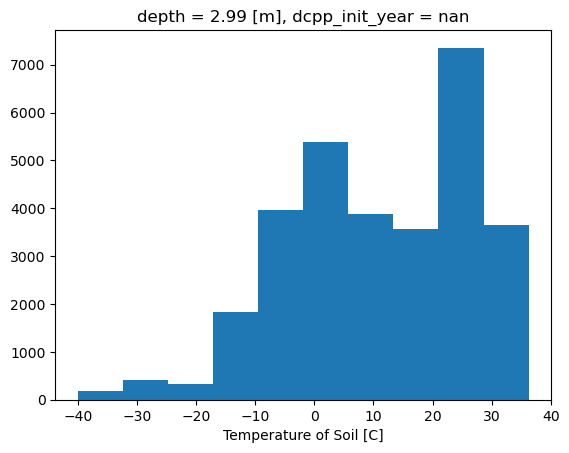

In [24]:
# if we try to subset the tsl data-array with now 5 dimensions (see above) and plot a time slice, you will get nonsense
tsl=ds_cesm.tsl.sel(time=slice("2000-01","2000-12")).sel(depth=3.0, method="nearest").mean(dim='time',keep_attrs=True)
tsl.values=tsl.values-273.15
attrs = tsl.attrs
attrs.update({"units" : "C"})
tsl.plot()

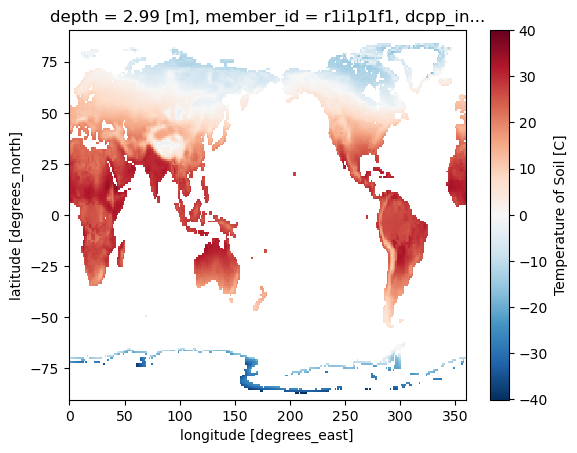

In [27]:
# to not get nonsense, you will have to reduce the number of dimensions:
# first, we squeeze singleton dimensions (in this case dccp_init_year)
ds_cesm_squized = ds_cesm.squeeze()
# then,  we can just normally select the member_id we want)
ds_cesm_squized = ds_cesm_squized.sel(member_id = 'r1i1p1f1')
# now we can actually plot the annual temperature map for 3 m depth
tsl=ds_cesm_squized.tsl.sel(time=slice("2000-01","2000-12")).sel(depth=3.0, method="nearest").mean(dim='time',keep_attrs=True)
tsl.values=tsl.values-273.15
attrs = tsl.attrs
attrs.update({"units" : "C"})
tsl.plot()

##  Tips for local NorESM catalog.

In [ ]:
noresm_catalog = intake.open_esm_datastore('/mnt/clinfra-ns12127k/catalogs/noresm.json')
#load the catalog again, just in case

### Let's see what variables are available for the historical period on a daily resolution

In [38]:
noresm_subset=noresm_catalog.search(experiment_id='historical')
# you can chain .search()
print("table_ids for historical:")
print(noresm_subset.unique()['table_id'])
noresm_subset=noresm_subset.search(table_id='day')
print("variable_ids for day table in historical:")
noresm_subset.unique()['variable_id']
noresm_subset=noresm_subset.search(variable_id='tas',source_id='NorESM2-LM')
print("tas for NorESM2-LM for day table in historical:")
noresm_subset.unique()
# you can subset things further if you want

table_ids for historical:
['AERmon', 'Omon', 'Oyr', 'Amon', 'day', 'Oday', 'SImon', 'SIday', 'EmonZ', 'Emon', 'Lmon', 'LImon', 'Eday', '6hrPlev', 'CFday', 'E3hr', 'CFmon', '3hr', 'AERday', '6hrLev', '6hrPlevPt', 'CF3hr']
variable_ids for day table in historical:
tas for NorESM2-LM for day table in historical:


variable_id                                                        [tas]
table_id                                                           [day]
source_id                                                   [NorESM2-LM]
experiment_id                                               [historical]
member_id                       [r1i1p1f1, r2i1p1f1, r3i1p1f1, r1i1p4f1]
grid_label                                                          [gn]
time_range             [18500101-18591231, 18600101-18691231, 1870010...
version                                [v20190815, v20190920, v20230616]
path                   [/mnt/tacco-ns1004k-cmroot/NorESM2-LM/historic...
dcpp_init_year                                                        []
derived_variable_id                                                   []
dtype: object